In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import cross_val_score
import time


## 1. Incarcam datele procesate

Sklearn-ul (RandomForest, XGBoost etc.) vrea y ca array 1D, nu 2D. Dacă dai un array (N, 1) primești warning sau eroare în unele versiuni.

In [61]:
X_train = pd.read_csv('../data/processed/X_train.csv',sep=',')
#transforma din shape(N,1) 2D in shape. de (N,) 1D 
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nDistributie train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Distributie test:  {pd.Series(y_test).value_counts().to_dict()}")

Train: (8274, 30)
Test:  (1409, 30)

Distributie train: {1: 4137, 0: 4137}
Distributie test:  {0: 1034, 1: 375}


## 2. Definim modelelel


### 1. Logistic Regression
max_iter=1000   # câte runde de optimizare are voie să facă
                # default e 100, dar cu multe features poate să nu conveargă
                # → mărești ca să fie sigur că găsește soluția
### 2. Random Forest
n_estimators=200  # câți arbori construiește
                  # mai mulți = mai stabil, dar mai lent
                  # 200 e un număr decent pentru churn

random_state=42   # reproducibilitate

n_jobs=-1         # folosește TOATE core-urile CPU în paralel
                  # fără asta, antrenează arborii unul câte unul (lent)

### 3. XGBoost
Spre deosebire de Random Forest unde arborii sunt independenți, XGBoost îi construiește secvențial — fiecare arbore nou încearcă să corecteze greșelile celui anterior (gradient boosting):

n_estimators=200      # câți arbori secvențiali construiește

learning_rate=0.1     # cât de mult "ascultă" fiecare arbore nou
                      # mic (0.05) = învață încet, mai precis, risc mic de overfit
                      # mare (0.3+) = învață repede, risc de overfit
                      # 0.1 e classic trade-off

max_depth=5           # cât de adânc poate fi fiecare arbore
                      # mai adânc = captează relații complexe, dar overfit
                      # 5 e standard pentru tabular data

eval_metric='logloss' # metrica folosită intern la antrenare
                      # logloss e bun pentru clasificare binară (churn yes/no)

### 4.LightGCM
Același principiu ca XGBoost (gradient boosting), dar mai rapid — crește arborii leaf-wise în loc de level-wise:

XGBoost  → extinde toți nodii de pe același nivel  (mai lent, mai uniform)
LightGBM → extinde doar nodul cu cel mai mare câștig (mai rapid, mai agresiv)


verbose=-1         # oprește spam-ul de loguri în consolă
                   # fără asta printează tone de text la fiecare run


In [62]:
models={
    'Logistic Regresion': LogisticRegression(max_iter=1000,random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators= 200 , random_state= 42, n_jobs=-1),
    'XGBoost' : XGBClassifier(n_estimators= 200, learning_rate= 0.1 ,max_depth= 5, eval_metric='logloss',random_state= 42 ),
    'LightGCM' : LGBMClassifier(n_estimators= 200, learning_rate= 0.1 ,max_depth= 5,verbose = -1,random_state=42)
}

In [63]:
results= [] 

for name,model in models.items():
    print("-" * 50)
    print(f"Antrenam: {name}")
    print("+"*50)

    start=time.time()
    model.fit(X_train,y_train)
    train_time=time.time()-start

    y_pred=model.predict(X_test)
    y_proba= model.predict_proba(X_test)[:,1]

    #Metrici
    acc=accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_proba)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'Train Time (s)': round(train_time, 2)
    })

    print(f"\nROC-AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

--------------------------------------------------
Antrenam: Logistic Regresion
++++++++++++++++++++++++++++++++++++++++++++++++++

ROC-AUC: 0.8517 | F1: 0.6376 | Recall: 0.7413

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1034
           1       0.56      0.74      0.64       375

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409

--------------------------------------------------
Antrenam: Random Forest
++++++++++++++++++++++++++++++++++++++++++++++++++

ROC-AUC: 0.8308 | F1: 0.5982 | Recall: 0.6213

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1034
           1       0.58      0.62      0.60       375

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
we

In [64]:
# Tabel comparativ
df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(df_results.to_string(index=False))

             Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
Logistic Regresion    0.7757     0.5594  0.7413    0.6376   0.8517            0.03
          LightGCM    0.7722     0.5587  0.6853    0.6156   0.8334            0.82
           XGBoost    0.7708     0.5565  0.6827    0.6132   0.8326            0.35
     Random Forest    0.7779     0.5767  0.6213    0.5982   0.8308            0.21


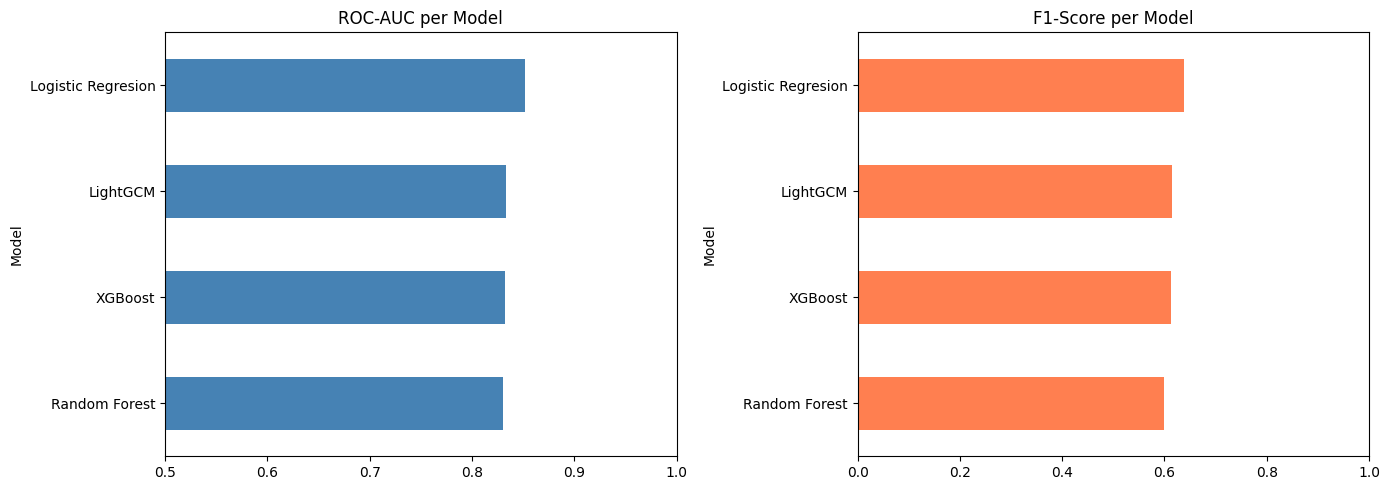

In [65]:
# Grafic comparativ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC
df_results.sort_values('ROC-AUC').plot(
    kind='barh', x='Model', y='ROC-AUC', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('ROC-AUC per Model')
axes[0].set_xlim(0.5, 1.0)

# F1-Score
df_results.sort_values('F1-Score').plot(
    kind='barh', x='Model', y='F1-Score', ax=axes[1], color='coral', legend=False)
axes[1].set_title('F1-Score per Model')
axes[1].set_xlim(0.0, 1.0)

plt.tight_layout()
plt.show()

Cel mai bun model: Logistic Regresion


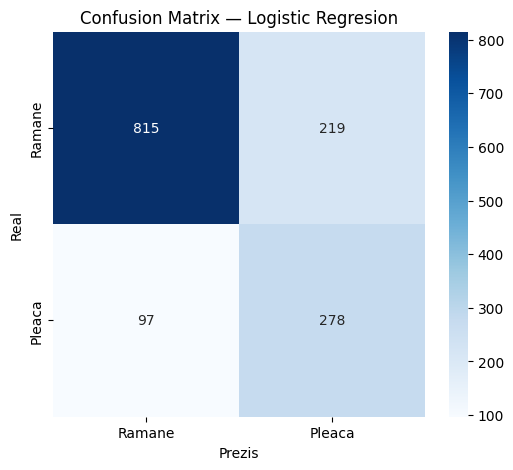


True Negatives (corect ramane): 815
False Positives (gresit prezis pleaca): 219
False Negatives (ratat churner): 97
True Positives (corect prezis pleaca): 278


In [ ]:
best_name = df_results.iloc[0]['Model']
best_model = models[best_name]
print(f"Cel mai bun model: {best_name}")

y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ramane', 'Pleaca'],
            yticklabels=['Ramane', 'Pleaca'])
plt.xlabel('Prezis')
plt.ylabel('Real')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

print(f"\nTrue Negatives (corect ramane): {cm[0][0]}")
print(f"False Positives (gresit prezis pleaca): {cm[0][1]}")
print(f"False Negatives (ratat churner): {cm[1][0]}")
print(f"True Positives (corect prezis pleaca): {cm[1][1]}")

In [67]:
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(best_name, '../models/best_model_name.pkl')
joblib.dump(X_train.columns.tolist(), '../models/feature_names.pkl')
print("Salvat!")

Salvat!
